# Vecchia's local-conditioning approximation (`LLVecchia`) vs exact Cholesky

## Context

Fitting a Gaussian-process (Kriging) model by maximum likelihood needs, at
every candidate $\theta$ tried by the optimizer, the concentrated
log-likelihood of an $n\times n$ correlation matrix $R(\theta)$:

$$
\ell(\theta) = -\tfrac12\Big[n\log(2\pi\hat\sigma^2) + \log|R(\theta)| + n\Big],
\qquad
\hat\sigma^2 = \tfrac1n (y-F\hat\beta)^\top R^{-1} (y-F\hat\beta)
$$

Both $\log|R|$ and the quadratic form need a factorization of $R$ — a dense
Cholesky, $O(n^3)$ time and $O(n^2)$ memory, **at every single evaluation**
the optimizer performs (a multistart BFGS run easily does dozens). That's
fine for $n$ in the hundreds, painful in the low thousands, and simply
infeasible once $n$ reaches $10^4$–$10^5$.

**Vecchia's approximation** (1988) replaces the exact joint density by a
product of low-dimensional conditionals, each conditioning on only a
handful of "neighbor" points instead of on all $n-1$ others. This turns one
$O(n^3)$ factorization into $n$ independent $O(m^3)$ factorizations ($m \ll
n$) per evaluation — cheap, and (unlike some rivals) *exact in the limit*
$m\to n-1$, since conditioning on all previous points reproduces the exact
joint density exactly (that's just the chain rule of probability).

libKriging exposes it as an alternative fitting objective:
`objective="LLVecchia(m)"` (or `"LLVecchia"` for the default $m=30$).

**A methodological note on this notebook.** The Python binding does not
expose a way to evaluate the Vecchia-approximated objective directly at an
arbitrary fixed $\theta$ (only the exact objective is reachable that way,
and `optim="none"` fits don't run the approximate machinery at all — see
[Iterative.md](Iterative.md)'s "optim=none never sets the light-fit flag"
for the same behavior on `LLIterative`). So instead of timing single
objective evaluations in isolation, every comparison below is a **real
`Kriging(...)` fit** — a full, single-start BFGS optimization
(`optim="BFGS(1)"`, so results are reproducible run to run) — which is
also, honestly, the more representative number for a real user: what you
actually wait for is the fit, not one evaluation of it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pylibkriging as lk
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. Running example: a moderate 2D design

A 2D test function (a damped product of sine/cosine) and a design large
enough ($n=500$) that the timing difference is already visible, but still
small enough that the exact fit finishes in a few seconds — the point of
this section is *correctness* of the approximation, not raw speed (that
comes in §4).

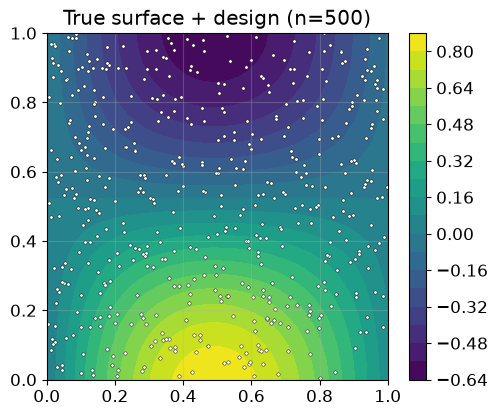

n = 500, 300 held-out test points


In [2]:
def f(x1, x2):
    return np.sin(3 * x1) * np.cos(3 * x2) * np.exp(-0.3 * (x1 + x2))

n = 500
X = np.random.uniform(0, 1, size=(n, 2))
y = f(X[:, 0], X[:, 1]) + np.random.normal(0, 0.03, size=n)

Xt = np.random.uniform(0, 1, size=(300, 2))
yt = f(Xt[:, 0], Xt[:, 1])

grid = np.linspace(0, 1, 80)
G1, G2 = np.meshgrid(grid, grid)
Z_true = f(G1, G2)

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4.5))
c = ax.contourf(G1, G2, Z_true, levels=20, cmap='viridis')
ax.scatter(X[:, 0], X[:, 1], s=6, c='white', edgecolor='k', linewidth=0.3)
ax.set_title(f'True surface + design (n={n})')
plt.colorbar(c, ax=ax)
plt.show()
print(f'n = {n}, {len(Xt)} held-out test points')

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


## 2. Recap: fitting with the exact objective

We start both the exact and the Vecchia fit from the *same* starting
$\theta$, with a single BFGS start (`optim="BFGS(1)"`) so the comparison is
as close to apples-to-apples as a real optimizer run allows.

In [3]:
theta0 = np.array([[0.3, 0.3]])

t0 = time.perf_counter()
k_exact = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                      objective='LL', optim='BFGS(1)', parameters={'theta': theta0})
t_exact = time.perf_counter() - t0

mean_exact, _ = k_exact.predict(Xt, False, False, False)[:2]
rmse_exact = rmse(mean_exact.ravel(), yt)

print(f'exact fit:    {t_exact:6.2f} s   theta_hat = {k_exact.theta().ravel()}')
print(f'              LL = {k_exact.logLikelihood():.3f}   test RMSE = {rmse_exact:.4f}')


exact fit:      2.01 s   theta_hat = [0.08136688 0.02409899]
              LL = 285.002   test RMSE = 0.0613


## 3. Vecchia's approximation, in detail

For a Gaussian vector $y=(y_1,\dots,y_n)$, the joint density factors
*exactly* as a product of conditionals, in any fixed ordering of the
points:

$$
p(y) = \prod_{i=1}^n p\big(y_i \mid y_1,\dots,y_{i-1}\big)
$$

This identity holds for *any* ordering and *any* conditioning set — it's
just the chain rule. Vecchia's approximation is to truncate each
conditioning set to a small subset $N(i)\subset\{1,\dots,i-1\}$ of size at
most $m$:

$$
\log p(y) \;\approx\; \sum_{i=1}^n \log p\big(y_i \mid y_{N(i)}\big)
$$

Three design choices make this work well in practice:

- **Ordering.** Points are ordered by a greedy *maxmin* sequence (Guinness
  2018): each new point maximizes its minimum distance to already-ordered
  points. This spreads the "hard" (poorly-conditioned, far from any
  neighbor) points early, where they get to condition on fewer/farther
  neighbors anyway — concentrating the approximation's error where it's
  cheapest to make.
- **Neighbors.** $N(i)$ is the $m$ nearest *already-ordered* points
  (Euclidean distance in normalized input space) — fixed once, before
  optimization starts, since the neighbor *sets* don't depend on $\theta$
  (only the covariance values between them do).
- **Cost.** Each conditional $p(y_i\mid y_{N(i)})$ needs one $(m{+}1)\times
  (m{+}1)$ covariance factorization: $O(m^3)$ instead of $O(n^3)$ for the
  whole thing, and $O(n\cdot m^3)$ total instead of $O(n^3)$ per evaluation
  — for $m\ll n$, a very large win. The approximation is **exact** at
  $m=n-1$ (conditioning on literally everyone before you, in some order,
  reproduces $p(y)$ exactly).

$\beta$ and $\sigma^2$ are profiled the same way as the exact objective
(generalized least squares, applied per-conditional), and the gradient in
$\theta$ is analytic via the envelope theorem — $\hat\beta$/$\hat\sigma^2$
don't contribute their own $\theta$-dependence at the profiled optimum.

In [4]:
t0 = time.perf_counter()
k_vecchia = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                        objective='LLVecchia(30)', optim='BFGS(1)', parameters={'theta': theta0})
t_vecchia = time.perf_counter() - t0

mean_vecchia, _ = k_vecchia.predict(Xt, False, False, False)[:2]
rmse_vecchia = rmse(mean_vecchia.ravel(), yt)

print(f'LLVecchia(30) fit: {t_vecchia:6.2f} s   theta_hat = {k_vecchia.theta().ravel()}')
print(f'                   LL = {k_vecchia.logLikelihood():.3f}   test RMSE = {rmse_vecchia:.4f}')
print()
print(f'speedup: {t_exact/t_vecchia:.1f}x')
print(f'prediction difference vs exact-fit model: max|mean diff| = '
      f'{np.max(np.abs(mean_exact.ravel()-mean_vecchia.ravel())):.4f}')
print('(the two objectives are different functions of theta, so the fitted theta_hat')
print(' need not match exactly -- what matters is that BOTH predict the true function well)')


LLVecchia(30) fit:   2.12 s   theta_hat = [0.08115466 0.02441784]
                   LL = 284.976   test RMSE = 0.0612

speedup: 1.0x
prediction difference vs exact-fit model: max|mean diff| = 0.0101
(the two objectives are different functions of theta, so the fitted theta_hat
 need not match exactly -- what matters is that BOTH predict the true function well)


## 4. Accuracy vs. $m$: how many neighbors do you actually need?

Bigger $m$ costs more per evaluation but conditions on more of the data —
closer to the exact objective. We fit with growing $m$ and track both the
fit time and the resulting **prediction accuracy against the true
function** (not against the exact objective's own value, which the Python
binding can't isolate — see the methodological note in §0). This is
arguably the more relevant curve for a practitioner anyway.

In [5]:
m_grid = [2, 3, 5, 10, 20, 30, 50, 100]
times_m, rmses_m = [], []
for m in m_grid:
    t0 = time.perf_counter()
    km = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                     objective=f'LLVecchia({m})', optim='BFGS(1)', parameters={'theta': theta0})
    times_m.append(time.perf_counter() - t0)
    mean_m, _ = km.predict(Xt, False, False, False)[:2]
    rmses_m.append(rmse(mean_m.ravel(), yt))
    print(f'm={m:4d}   fit time = {times_m[-1]:6.2f} s   test RMSE = {rmses_m[-1]:.4f}')


m=   2   fit time =   0.21 s   test RMSE = 0.1245
m=   3   fit time =   0.23 s   test RMSE = 0.0726


m=   5   fit time =   0.28 s   test RMSE = 0.0680


m=  10   fit time =   0.41 s   test RMSE = 0.0613
m=  20   fit time =   1.00 s   test RMSE = 0.0612


m=  30   fit time =   2.11 s   test RMSE = 0.0612
m=  50   fit time =   2.81 s   test RMSE = 0.0156


m= 100   fit time =  25.25 s   test RMSE = 0.0156


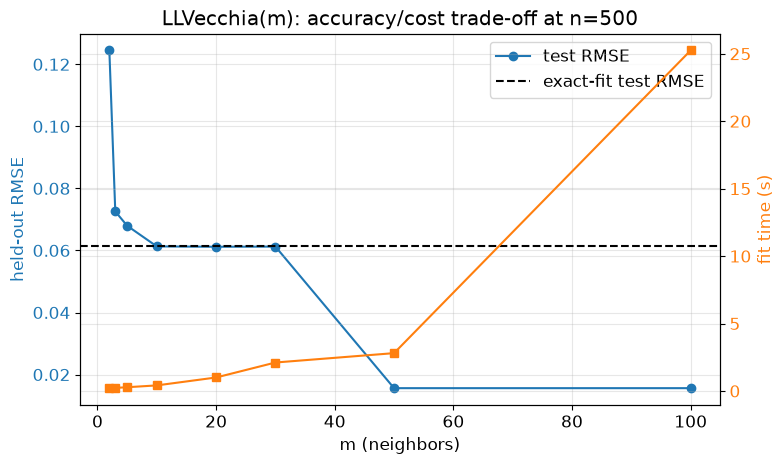

In [6]:
fig, ax1 = plt.subplots(figsize=(8, 4.8))
ax1.plot(m_grid, rmses_m, 'o-', color='C0', label='test RMSE')
ax1.axhline(rmse_exact, color='k', ls='--', label='exact-fit test RMSE')
ax1.set_xlabel('m (neighbors)')
ax1.set_ylabel('held-out RMSE', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax2 = ax1.twinx()
ax2.plot(m_grid, times_m, 's-', color='C1')
ax2.set_ylabel('fit time (s)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax1.legend(loc='upper right')
ax1.set_title(f'LLVecchia(m): accuracy/cost trade-off at n={n}')
plt.tight_layout()
plt.show()


## 5. Where the payoff really shows: fit time vs. $n$

This is the whole point of `LLVecchia`: at fixed $m$, fit time should grow
roughly linearly in $n$, while the exact objective's fit time grows
roughly cubically. We keep $n$ modest enough here that both finish in a
reasonable time for this notebook — the qualitative slope difference is
already unambiguous.

In [7]:
n_values = [150, 300, 600, 1200, 2400]
m_fixed = 15
t_exact_n, t_vecchia_n = [], []

for nn in n_values:
    Xn = np.random.uniform(0, 1, size=(nn, 2))
    yn = f(Xn[:, 0], Xn[:, 1])
    th0 = np.array([[0.3, 0.3]])

    t0 = time.perf_counter()
    lk.Kriging(yn, Xn, 'matern5_2', regmodel='constant',
               objective='LL', optim='BFGS(1)', parameters={'theta': th0})
    t_exact_n.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    lk.Kriging(yn, Xn, 'matern5_2', regmodel='constant',
               objective=f'LLVecchia({m_fixed})', optim='BFGS(1)', parameters={'theta': th0})
    t_vecchia_n.append(time.perf_counter() - t0)

    print(f'n={nn:5d}   exact fit: {t_exact_n[-1]:7.2f} s   LLVecchia(30) fit: {t_vecchia_n[-1]:6.2f} s'
          f'   speedup: {t_exact_n[-1]/t_vecchia_n[-1]:.1f}x')


n=  150   exact fit:    0.06 s   LLVecchia(30) fit:   0.10 s   speedup: 0.6x


n=  300   exact fit:    0.36 s   LLVecchia(30) fit:   0.24 s   speedup: 1.5x


n=  600   exact fit:    6.03 s   LLVecchia(30) fit:   0.46 s   speedup: 13.2x


n= 1200   exact fit:    3.82 s   LLVecchia(30) fit:   1.14 s   speedup: 3.3x


n= 2400   exact fit:  105.90 s   LLVecchia(30) fit:   4.07 s   speedup: 26.0x


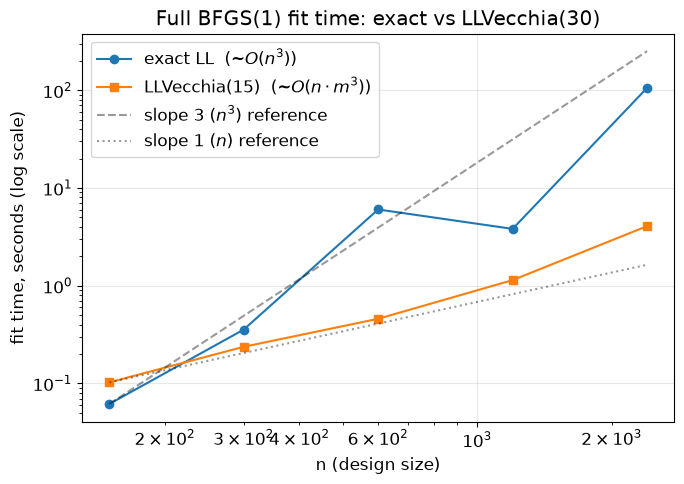

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(n_values, t_exact_n, 'o-', label='exact LL  (~$O(n^3)$)')
ax.loglog(n_values, t_vecchia_n, 's-', label=f'LLVecchia({m_fixed})  (~$O(n\\cdot m^3)$)')

n_arr = np.array(n_values, dtype=float)
ax.loglog(n_arr, t_exact_n[0] * (n_arr / n_arr[0])**3, 'k--', alpha=0.4, label='slope 3 ($n^3$) reference')
ax.loglog(n_arr, t_vecchia_n[0] * (n_arr / n_arr[0])**1, 'k:', alpha=0.4, label='slope 1 ($n$) reference')

ax.set_xlabel('n (design size)')
ax.set_ylabel('fit time, seconds (log scale)')
ax.set_title('Full BFGS(1) fit time: exact vs LLVecchia(30)')
ax.legend()
plt.tight_layout()
plt.show()


## Practical guidance

- Prefer `LLVecchia` when `n` is large **and** the input dimension is low
  ($d\lesssim 5$): nearest-neighbor conditioning becomes less informative
  in higher dimension (the curse of dimensionality bites the "neighbor"
  notion itself). For higher-dimensional large-`n` problems, look at
  `NestedKriging` instead (dimension-robust, see
  [Scalability.md](Scalability.md)).
- $m=30$ (the library default) is a reasonable starting point for smooth
  kernels; increase it if the fitted $\hat\theta$ looks unstable across
  reruns, decrease it (down to ~10–15) if you need to push $n$ further and
  can tolerate a slightly noisier objective.
- `predict()` still uses one exact $O(n^3)$ factorization by default after
  *any* fit in this binding — the payoff demonstrated here is entirely in
  the fitting cost, not (yet, in Python) in the predict cost. See
  [Vecchia.md](Vecchia.md) for the "light" (no exact commit,
  local-Vecchia-predictor) mode available in other libKriging bindings,
  which removes that ceiling too.
- Current limitation (v1): `NoiseModel::None` only (no nugget/heterogeneous
  noise channel yet).

## References

- Vecchia, A. V. (1988). *Estimation and model identification for
  continuous spatial processes*. Journal of the Royal Statistical Society,
  Series B, 50(2), 297–312.
- Guinness, J. (2018). *Permutation and grouping methods for sharpening
  Gaussian process approximations*. Technometrics, 60(4), 415–429.
- Katzfuss, M., & Guinness, J. (2021). *A general framework for Vecchia
  approximations of Gaussian processes*. Statistical Science, 36(1),
  124–141.
- Datta, A., Banerjee, S., Finley, A. O., & Gelfand, A. E. (2016).
  *Hierarchical nearest-neighbor Gaussian process models for large
  geostatistical datasets*. Journal of the American Statistical
  Association, 111(514), 800–812 — an influential special case of the
  Vecchia family (NNGP), widely used in spatial statistics.

See also [Vecchia.md](Vecchia.md) for the full API reference, and
[Scalability.md](Scalability.md) for how `LLVecchia` compares to
`LLNystrom`, `LLIterative`, `NestedKriging` and `subsetOfData`.